# Chart Farrer by-election at Sportsbet

## Python set-up

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import mgplot as mg
import numpy as np
from common import RFOOTER

In [2]:
# plotting constants
LFOOTER = (
    "Betting odds observed daily at sportsbet.com.au "
    + "(gaps = missing observations). "
)
footers = {"lfooter": LFOOTER, "rfooter": RFOOTER}
SHOW = True

# candidate colours for Farrer by-election
# (supplements mg.get_color() which doesn't know all candidate labels)
FARRER_COLORS: dict[str, str] = {
    "Independent": "darkorange",
    "Nationals": "forestgreen",
    "One Nation": "#f36c21",  # One Nation orange
    "Liberal Party": "royalblue",
    "Labor": "#dd0000",
    "Greens": "limegreen",
}


def farrer_colorise(names: pd.Index | list[str]) -> list[str]:
    """Return colours for Farrer by-election candidates."""
    return [FARRER_COLORS.get(n, "darkgrey") for n in names]

In [3]:
# plotting directory set-up
def set_up_plotting() -> None:
    """Set up plotting."""

    mg.set_chart_dir("../charts/farrer-by-election/")
    mg.clear_chart_dir()


set_up_plotting()

## Get data

In [4]:
def get_odds_data() -> pd.DataFrame:
    """Get the data for the Farrer by-election betting odds."""

    # --- read the data
    file_name = "../betting-data/sportsbet-2026-farrer-by-election.csv"
    try:
        df: pd.DataFrame = pd.read_csv(file_name, index_col=0)
    except FileNotFoundError:
        raise FileNotFoundError(f"Data file not found: {file_name}")
    except pd.errors.EmptyDataError:
        raise ValueError(f"Data file is empty: {file_name}")

    # --- validate columns
    if "Party" not in df.columns or "Odds" not in df.columns:
        raise ValueError(
            f"Unexpected CSV format. Expected 'Party' and 'Odds' columns, "
            f"got: {list(df.columns)}"
        )

    if df.empty:
        raise ValueError("No data found in CSV file")

    # --- pivot and process data
    df = df.pivot(columns="Party", values="Odds")

    # Convert to PeriodIndex and remove duplicates
    df.index = pd.PeriodIndex(df.index, freq="D")
    df = df[~df.index.duplicated(keep="first")].sort_index()

    # --- fill in missing dates
    if len(df) > 0:
        new_index = pd.period_range(
            start=df.index.min(), end=df.index.max(), freq="D"
        )
        df = df.reindex(new_index, fill_value=None)

    # Convert odds to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    print(
        f"Successfully loaded data with {len(df)} rows and "
        f"{len(df.columns)} candidates: {list(df.columns)}"
    )
    return df


core_odds = get_odds_data()

Successfully loaded data with 24 rows and 6 candidates: ['Greens', 'Independent', 'Labor', 'Liberal Party', 'Nationals', 'One Nation']


In [5]:
def convert(odds: pd.DataFrame) -> pd.DataFrame:
    """
    Convert decimal odds to adjusted probabilities
    (ie, scaled to sum to one; addressing the bookmaker's over-round).
    """

    if odds.empty:
        raise ValueError("Cannot convert empty odds DataFrame")

    # Replace non-positive with NaN
    odds = odds.where(odds > 0)

    if odds.isnull().all().all():
        raise ValueError("No valid positive odds found")

    # get raw probabilities (1/odds)
    with np.errstate(divide="ignore", invalid="ignore"):
        raw_probs = 1 / odds

    # remove the bookmaker's over-round
    total = raw_probs.sum(axis=1)
    probability = raw_probs.div(total, axis=0)

    # Convert to percentage
    result = probability * 100

    valid_data_points = result.notna().sum().sum()
    total_data_points = result.size
    print(
        f"Probability conversion: {valid_data_points}/{total_data_points} "
        "valid data points"
    )

    return result


adj_probs = convert(core_odds)

Probability conversion: 132/144 valid data points


## Chart 1: Latest win probabilities

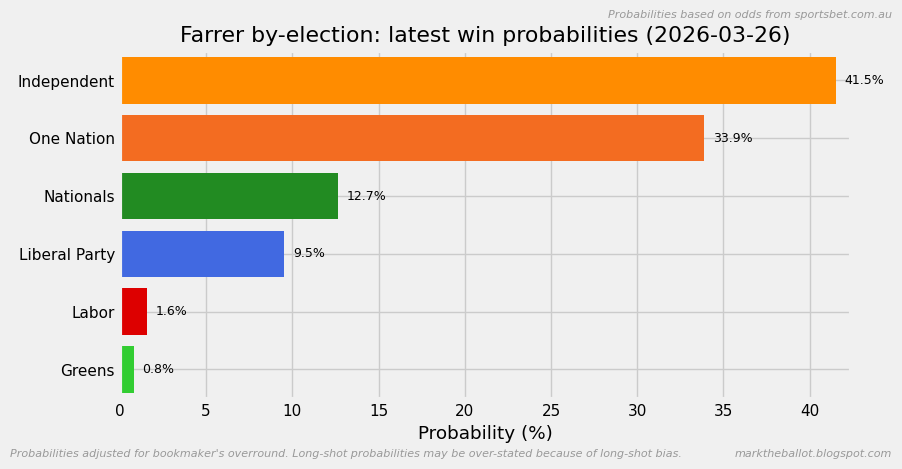

In [6]:
def plot_latest_probabilities(df: pd.DataFrame) -> None:
    """Plot the latest win probabilities as a horizontal bar chart."""

    # Get the last row with non-null data
    latest = df.dropna(how="all").iloc[-1].dropna().sort_values(ascending=True)

    if latest.empty:
        print("Warning: No data to plot")
        return

    colors = farrer_colorise(latest.index)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bars = ax.barh(
        range(len(latest)),
        latest.values,
        color=colors,
    )
    ax.set_yticks(range(len(latest)))
    ax.set_yticklabels(latest.index)

    # Annotate bars with probability values
    for bar, value in zip(bars, latest.values):
        x_pos = bar.get_width()
        ax.text(
            x_pos + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
        )

    capture_date = df.dropna(how="all").index[-1]
    lfooter = (
        "Probabilities adjusted for bookmaker's overround. "
        "Long-shot probabilities may be over-stated because of long-shot bias. "
    )
    mg.finalise_plot(
        ax,
        title=f"Farrer by-election: latest win probabilities ({capture_date})",
        rheader="Probabilities based on odds from sportsbet.com.au",
        xlabel="Probability (%)",
        ylabel=None,
        lfooter=lfooter,
        rfooter=RFOOTER,
        show=SHOW,
    )


plot_latest_probabilities(adj_probs)

## Chart 2: Odds over time

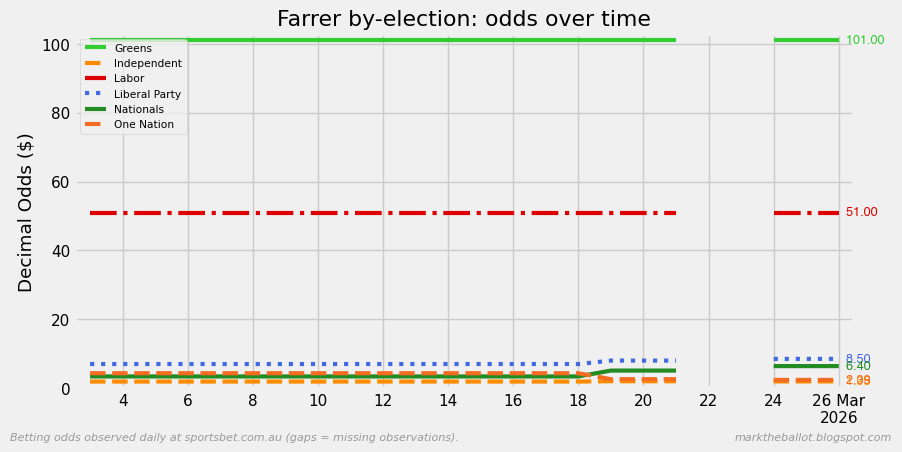

In [7]:
def plot_odds(df: pd.DataFrame) -> None:
    """Plot the betting odds over time."""

    if df.empty or df.isnull().all().all():
        print("Warning: No data to plot")
        return

    if len(df.dropna(how="all")) < 2:
        print("Warning: Need at least 2 days of data for time series plot")
        return

    colors = farrer_colorise(df.columns)
    mg.multi_start(
        df,
        function=mg.line_plot_finalise,
        starts=(0,),
        color=colors,
        title="Farrer by-election: odds over time",
        xlabel=None,
        ylabel="Decimal Odds ($)",
        legend=True,
        width=3,
        annotate=True,
        rounding=2,
        dropna=False,
        **footers,
        show=SHOW,
    )


plot_odds(core_odds)

## Chart 3: Win probabilities over time

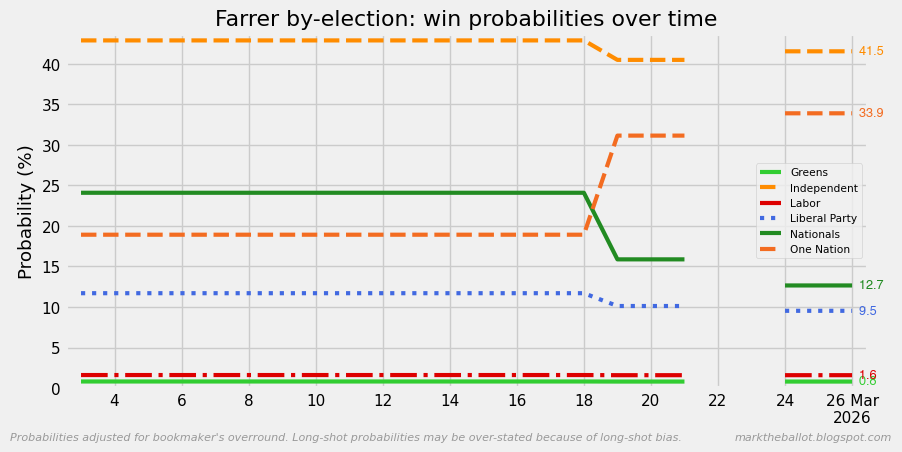

In [8]:
def plot_probabilities(df: pd.DataFrame) -> None:
    """Plot the adjusted probabilities over time."""

    if df.empty or df.isnull().all().all():
        print("Warning: No data to plot")
        return

    if len(df.dropna(how="all")) < 2:
        print("Warning: Need at least 2 days of data for time series plot")
        return

    colors = farrer_colorise(df.columns)
    lfooter = (
        "Probabilities adjusted for bookmaker's overround. "
        "Long-shot probabilities may be over-stated because of long-shot bias. "
    )
    mg.multi_start(
        df,
        function=mg.line_plot_finalise,
        starts=(0,),
        color=colors,
        title="Farrer by-election: win probabilities over time",
        xlabel=None,
        ylabel="Probability (%)",
        legend=True,
        width=3,
        annotate=True,
        rounding=1,
        dropna=False,
        lfooter=lfooter,
        rfooter=RFOOTER,
        show=SHOW,
    )


plot_probabilities(adj_probs)

## Finished

In [9]:
%load_ext watermark
%watermark -t -d -u --python --machine --conda --iversions --watermark

Last updated: 2026-03-26 21:03:26

Python implementation: CPython
Python version       : 3.14.0
IPython version      : 9.11.0

conda environment: n/a

Compiler    : Clang 20.1.4 
OS          : Darwin
Release     : 25.3.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

matplotlib: 3.10.8
mgplot    : 0.2.21
numpy     : 2.4.3
pandas    : 3.0.1

Watermark: 2.6.0



In [10]:
print("It is done")

It is done
